In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import sys
print(sys.executable)

/Users/francoisdubreu/Projects Python/causal-jump-diffusion/.venv/bin/python


In [8]:
# Cellule 1 : Imports et Configuration
import sys
import os
import torch
import matplotlib.pyplot as plt

# Astuce pour importer les modules depuis le dossier 'src' qui est un niveau au-dessus
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Maintenant on peut importer ton module proprement
from neural_quant.models.jumps import NeuralHawkes

# Pour que les graphiques soient jolis
%matplotlib inline 
plt.rcParams['figure.figsize'] = [12, 6]

print("Imports réussis ! Prêt à tester.")

Imports réussis ! Prêt à tester.


Simulation en cours...


<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
/var/folders/4y/t44tfszn4dx05bvjg6hnlk8h0000gn/T/ipykernel_20042/1582854760.py:50: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(intensities, color='blue', label='Intensité Hawkes $\lambda_t$')


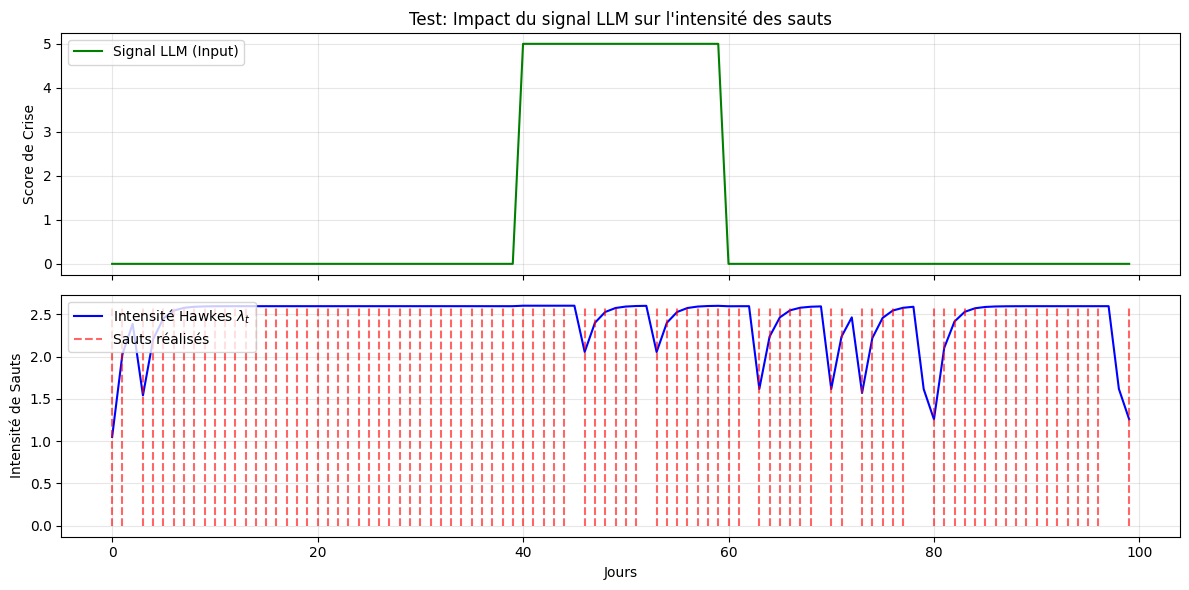

In [9]:
# Cellule 2 : Simulation et Visualisation

def run_test():
    # 1. Initialisation du modèle
    # input_dim=1 car on teste avec un seul signal (score de news)
    model = NeuralHawkes(input_dim=1, hidden_dim=16)
    
    # 2. Paramètres de simulation
    dt = 1.0       # Pas de temps (1 jour)
    days = 100     # Durée
    
    # Scénario : Le marché est calme, puis une crise éclate (t=40 à 60)
    llm_signal = torch.zeros(days, 1)
    llm_signal[40:60] = 5.0 # Signal fort "News négative"
    
    intensities = []
    jumps = torch.zeros(1, days) # Historique des sauts
    
    print("Simulation en cours...")
    
    # 3. Boucle temporelle
    for t in range(days):
        # On récupère le signal du jour t
        ctx = llm_signal[t].unsqueeze(0) 
        
        # Historique glissant pour l'auto-excitation
        start_win = max(0, t-10)
        recent_jumps = jumps[:, start_win:t] if t > 0 else None
        
        # Le modèle calcule l'intensité lambda
        lambda_t = model(ctx, dt=dt, past_jumps=recent_jumps)
        intensities.append(lambda_t.item())
        
        # On tire un dé pour voir si un saut se produit (Loi de Poisson locale)
        prob_jump = 1 - torch.exp(-lambda_t * dt)
        if torch.rand(1) < prob_jump:
            jumps[0, t] = 1.0
    
    # 4. Affichage
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
    
    # Graphique du haut : Le signal LLM
    ax1.plot(llm_signal.numpy(), color='green', label='Signal LLM (Input)')
    ax1.set_ylabel('Score de Crise')
    ax1.set_title('Test: Impact du signal LLM sur l\'intensité des sauts')
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)
    
    # Graphique du bas : L'intensité résultante et les sauts
    ax2.plot(intensities, color='blue', label='Intensité Hawkes $\lambda_t$')
    
    # On dessine les sauts (barres rouges)
    jump_indices = torch.where(jumps[0] == 1)[0]
    if len(jump_indices) > 0:
        ax2.vlines(jump_indices, 0, max(intensities), colors='red', linestyles='dashed', alpha=0.6, label='Sauts réalisés')
        
    ax2.set_ylabel('Intensité de Sauts')
    ax2.set_xlabel('Jours')
    ax2.legend(loc="upper left")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Lancer le test
run_test()

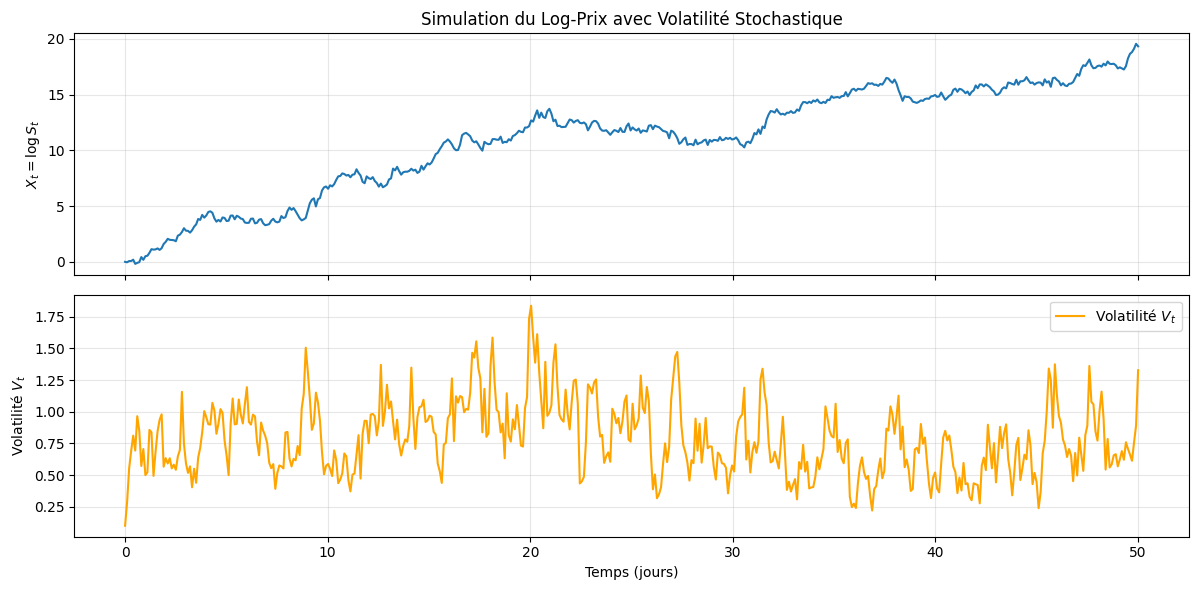

In [12]:
# Cellule 3 : Test de la Neural SDE (Mouvement Brownien + Volatilité)

import torch
import torchsde 
import matplotlib.pyplot as plt
from neural_quant.models.sde import NeuralSDE

def test_sde_simulation():
    # 1. Initialisation
    context_dim = 1
    hidden_dim = 16
    sde_model = NeuralSDE(context_dim=context_dim, hidden_dim=hidden_dim)
    
    # 2. Paramètres de simulation
    T = 50.0  
    N = 500   
    ts = torch.linspace(0, T, N) 
    
    # Condition initiale (X_0=0, V_0=0.1)
    y0 = torch.tensor([0.0, 0.1]).unsqueeze(0) 
    
    # 3. Résolution du SDE avec torchsde
    with torch.no_grad():
        y_path = torchsde.sdeint(sde_model, y0, ts, method="euler") 

    # 4. Trajectoires
    X_t = y_path[:, 0, 0].numpy()
    V_t = y_path[:, 0, 1].clamp_min(0).numpy()

    # 5. Visualisation
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
    
    # --- CORRECTION 3 : Utilisation de raw strings (r'...') pour le LaTeX ---
    ax1.plot(ts.numpy(), X_t, label=r'Log-Prix $X_t$')
    ax1.set_title('Simulation du Log-Prix avec Volatilité Stochastique')
    ax1.set_ylabel(r'$X_t = \log S_t$') # Le 'r' corrige le warning \l
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(ts.numpy(), V_t, color='orange', label=r'Volatilité $V_t$')
    ax2.set_ylabel(r'Volatilité $V_t$')
    ax2.set_xlabel('Temps (jours)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Lancement du test
if __name__ == '__main__':
    test_sde_simulation()